# AI Career Prediction - Random Forest Training

This notebook contains the script to train a Random Forest classifier for career prediction based on emotion and personality features.

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set directory shortcut
DATA_PATH = '../data/dataset.csv'
MODEL_DIR = '../models/'
os.makedirs(MODEL_DIR, exist_ok=True)

## 1. Load and Explore Dataset

In [3]:
df = pd.read_csv(DATA_PATH)
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (990, 19)


,angry,disgust,fear,happy,sad,surprise,neutral,openness,conscientiousness,extraversion,agreeableness,neuroticism,dominant_emotion_idx,emotion_entropy,emotion_variance,neutral_ratio,positive_ratio,negative_ratio,matched_career
0,0.116178,0.051344,0.118618,0.298603,0.109079,0.145801,0.160377,0.818213,0.550169,0.666391,0.846214,0.399305,3,1.832271,0.005055,0.160377,0.444404,0.395219,UI/UX Designer
1,0.116405,0.060782,0.082259,0.294569,0.119049,0.190186,0.136751,0.767378,0.804335,0.517783,0.559579,0.275312,3,1.827177,0.005281,0.136751,0.484755,0.378494,Cloud Architect
2,0.120324,0.065392,0.130600,0.260228,0.123060,0.171141,0.129256,0.709981,0.804709,0.423950,0.556935,0.508928,3,1.873693,0.003116,0.129256,0.431368,0.439376,Full Stack Developer
3,0.069354,0.071061,0.099969,0.310504,0.138207,0.135327,0.175578,0.521203,0.901972,0.178205,0.334209,0.214050,3,1.815967,0.005950,0.175578,0.445832,0.378591,Cybersecurity Analyst
4,0.081939,0.090444,0.099874,0.289679,0.109903,0.138629,0.189534,0.648722,0.858636,0.327180,0.531469,0.388585,3,1.843170,0.004735,0.189534,0.428308,0.382159,Software Developer


0


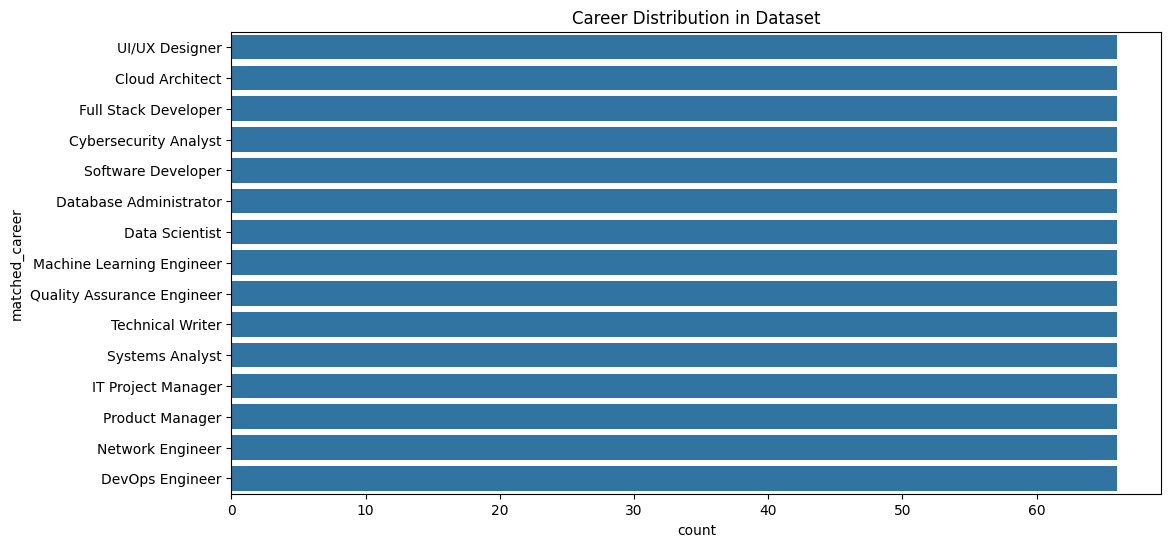

In [4]:
# Check for missing values
print(df.isnull().sum().sum())

# Check career distribution
plt.figure(figsize=(12, 6))
sns.countplot(y='matched_career', data=df, order=df['matched_career'].value_counts().index)
plt.title('Career Distribution in Dataset')
plt.show()

## 2. Preprocessing

In [5]:
# Encode Target Labels
le = LabelEncoder()
df['target'] = le.fit_transform(df['matched_career'])

# Define Features (Emotions + Personality + Engineered)
# As identified in backend/service/career_guide_service.py
feature_cols = [
    'angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral',
    'openness', 'conscientiousness', 'extraversion', 'agreeableness', 'neuroticism',
    'dominant_emotion_idx', 'emotion_entropy', 'emotion_variance',
    'neutral_ratio', 'positive_ratio', 'negative_ratio'
]

X = df[feature_cols]
y = df['target']

# Split into Train and Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (792, 18)
Test set size: (198, 18)


## 3. Train Random Forest Model

In [6]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_split=2, random_state=42)
rf_model.fit(X_train_scaled, y_train)

print("Random Forest Model Training Complete.")

Random Forest Model Training Complete.


## 4. Evaluation

In [7]:
y_pred = rf_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Model Accuracy: 0.8485

Classification Report:
                            precision    recall  f1-score   support

           Cloud Architect       0.69      0.69      0.69        13
     Cybersecurity Analyst       0.86      0.92      0.89        13
            Data Scientist       0.82      0.69      0.75        13
    Database Administrator       0.83      0.71      0.77        14
           DevOps Engineer       1.00      0.85      0.92        13
      Full Stack Developer       0.69      0.85      0.76        13
        IT Project Manager       0.86      0.86      0.86        14
 Machine Learning Engineer       0.69      0.69      0.69        13
          Network Engineer       0.83      0.77      0.80        13
           Product Manager       0.92      0.92      0.92        13
Quality Assurance Engineer       0.80      0.92      0.86        13
        Software Developer       0.86      0.92      0.89        13
           Systems Analyst       0.93      0.93      0.93        14


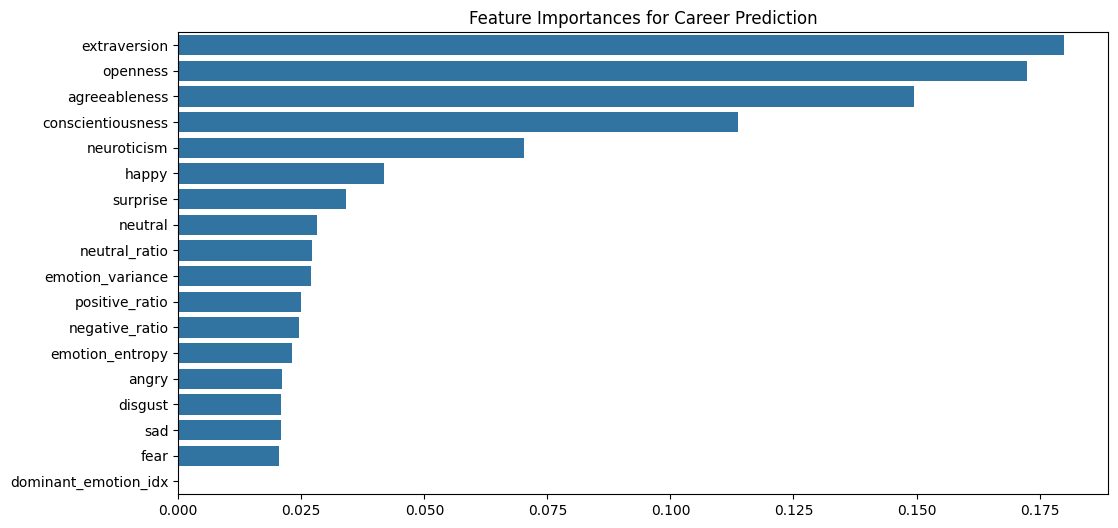

In [8]:
# Feature Importance Visualization
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12, 6))
sns.barplot(x=importances[indices], y=np.array(feature_cols)[indices])
plt.title('Feature Importances for Career Prediction')
plt.show()

## 5. Save Artifacts
Save the model, scaler, and label encoder for use in the FastAPI backend.

In [9]:
joblib.dump(rf_model, os.path.join(MODEL_DIR, 'career_prediction_model.joblib'))
joblib.dump(le, os.path.join(MODEL_DIR, 'career_label_encoder.joblib'))
joblib.dump(scaler, os.path.join(MODEL_DIR, 'feature_scaler.pkl'))

print(f"All artifacts saved to {MODEL_DIR}")

All artifacts saved to ../models/
